# Random Forest — SDY524 federated with the other institutions (SDY524's view)

**Stage 2.** The per-study notebooks (Stage 1) fit each institution on the four
LASSO-selected features (weight_kg, GAD65, received_active_treatment, Sex) and
wrote a model artifact. This notebook reads SDY524's partners'
artifacts (SDY569) and applies them to **SDY524's own
data** — showing what SDY524 gains by federating, without any subject-level data
leaving any institution.

**Solo**: SDY524 predicts its held-out subjects with its own model.
**Federated**: SDY524 combines its model with the partners' (read from disk) and
predicts the same subjects. We report R², MSE, and achieved power for both, and
the scatter of observed vs predicted.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings, pickle
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import f as fdist, ncf

import oadr_data as od

RNG_SEED = 42
SEL = ["weight_kg", "GAD65", "received_active_treatment", "Sex"]
THIS = "SDY524"
PARTNERS = ['SDY569']
np.random.seed(RNG_SEED)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo root:", REPO, "| THIS =", THIS, "| partners =", PARTNERS)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody | THIS = SDY524 | partners = ['SDY569']


## 2. Load SDY524's four-feature data and the partners' artifacts

SDY524's data is loaded locally. The partners' contributions are read from
disk — trained forests (`models/*_rf_sel.pkl`) — never their subjects.


In [2]:
def load4(s):
    b = od.load_panel_b(s)
    for c in ("bmi", "height_cm", "weight_kg"):
        b[c] = b[c].fillna(b[c].median())
    bad = b["height_cm"] <= 0
    b.loc[bad, "height_cm"] = np.sqrt(b.loc[bad, "weight_kg"] / b.loc[bad, "bmi"]) * 100
    X, y, _ = od.panel_b_design_matrix(b)
    return X.reindex(columns=SEL).values.astype(float), y.values.astype(float)

X4, y4 = load4(THIS)
print(f"{THIS}: N={len(y4)}, features={SEL}")

def read_partner_forest(s):
    with open(REPO / "models" / f"{s}_rf_sel.pkl", "rb") as fh:
        d = pickle.load(fh)
    return d["forest"], d["scaler"], d["n_subjects"]

partner_models = {s: read_partner_forest(s) for s in PARTNERS}
for s in PARTNERS:
    print(f"  partner {s}: loaded forest (N={partner_models[s][2]})")


SDY524: N=72, features=['weight_kg', 'GAD65', 'received_active_treatment', 'Sex']
  partner SDY569: loaded forest (N=10)


## 3. Solo vs federated — 5-fold cross-validation on SDY524

SDY524 holds out each fold, fits its own model on the rest, and predicts the
held-out subjects two ways: with its own model (**solo**) and with its model
combined with the partners' (Union-of-Forests, predictions averaged, **federated**). Power uses the four
predictors and the cohort size.


In [3]:
def calc_power(n, k, f2, alpha=0.05):
    if n <= k + 1 or f2 <= 0:
        return float("nan")
    return float(1 - ncf.cdf(fdist.ppf(1 - alpha, k, n - k - 1), k, n - k - 1, f2 * n))

def metrics(y, p):
    mask = ~np.isnan(p)
    mse = np.mean((y[mask] - p[mask]) ** 2)
    rss = np.sum((y[mask] - p[mask]) ** 2); tss = np.sum((y[mask] - y[mask].mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else float("nan")
    f2 = r2 / (1 - r2) if 0 < r2 < 1 else 0.0
    return mse, r2, calc_power(int(mask.sum()), len(SEL), f2)

kf = KFold(min(5, max(2, len(y4) // 2)), shuffle=True, random_state=RNG_SEED)
solo = np.full(len(y4), np.nan)
fed = np.full(len(y4), np.nan)
for tr, te in kf.split(X4):
    sc = MinMaxScaler().fit(X4[tr])
    model = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=1, random_state=RNG_SEED).fit(sc.transform(X4[tr]), y4[tr])
    solo[te] = model.predict(sc.transform(X4[te]))
    preds = [model.predict(sc.transform(X4[te]))]
    for s in PARTNERS:
        f_s, sc_s, _ = partner_models[s]
        preds.append(f_s.predict(sc_s.transform(X4[te])))
    fed[te] = np.mean(preds, axis=0)

mse_s, r2_s, pw_s = metrics(y4, solo)
mse_f, r2_f, pw_f = metrics(y4, fed)
print(f"{THIS} — Random Forest on the four selected features")
print(f"  solo      MSE={mse_s:.3f}  R2={r2_s:+.3f}  power={pw_s:.3f}")
print(f"  federated MSE={mse_f:.3f}  R2={r2_f:+.3f}  power={pw_f:.3f}")


SDY524 — Random Forest on the four selected features
  solo      MSE=0.116  R2=+0.158  power=0.824
  federated MSE=0.122  R2=+0.114  power=0.643


## 4. Presentation graphic — SDY524 solo vs federated


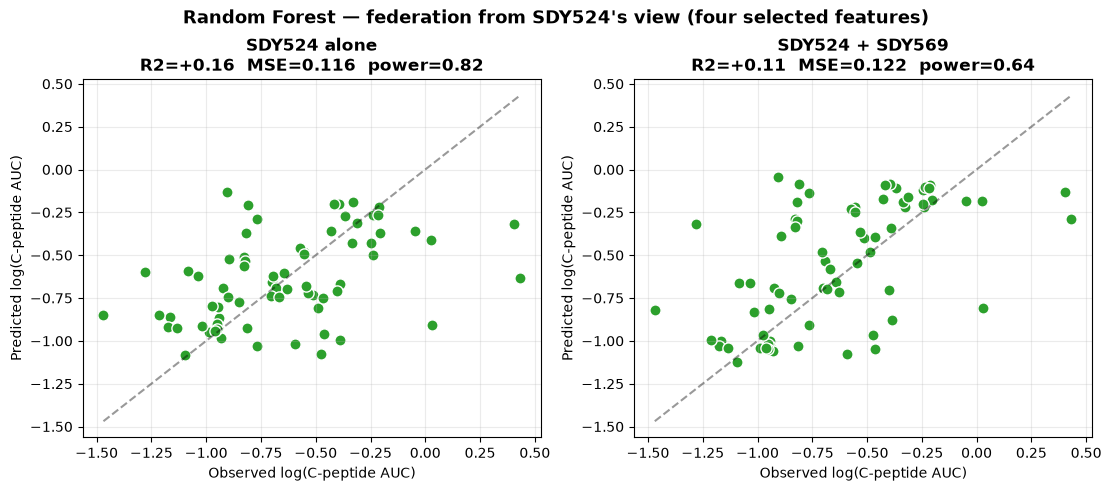

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
lo = min(y4.min(), np.nanmin(solo), np.nanmin(fed))
hi = max(y4.max(), np.nanmax(solo), np.nanmax(fed))
panels = [(solo, THIS + " alone", mse_s, r2_s, pw_s),
          (fed, THIS + " + " + "+".join(PARTNERS), mse_f, r2_f, pw_f)]
for ax, (pred, title, mse, r2, pw) in zip(axes, panels):
    ax.scatter(y4, pred, c="#2ca02c", s=65, edgecolor="white")
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_xlabel("Observed log(C-peptide AUC)")
    ax.set_ylabel("Predicted log(C-peptide AUC)")
    ax.set_title(f"{title}\nR2={r2:+.2f}  MSE={mse:.3f}  power={pw:.2f}", fontweight="bold")
    ax.grid(alpha=0.25)
fig.suptitle("Random Forest — federation from " + THIS + "'s view (four selected features)",
             fontsize=13, fontweight="bold")
fig.savefig(f"figures/RandomForest_{THIS}_federated.pdf", dpi=300)
fig.savefig(f"figures/RandomForest_{THIS}_federated.png", dpi=220)
plt.show()


## 5. Output

`figures/RandomForest_SDY524_federated.pdf` / `.png` — SDY524 solo vs
federated on the four LASSO-selected features, with R², MSE, and achieved power.
This is the within-institution view of what federation buys SDY524: the partner
forests were read from disk; no
subject-level data crossed institutions.
